Klasifikasi Kategori Produk Cokelat Menggunakan Algoritma K-Nearest Neighbors (KNN) Berdasarkan Karakteristik Produk

Penelitian ini bertujuan untuk menerapkan algoritma K-Nearest Neighbors (KNN) dalam mengklasifikasikan kategori produk cokelat berdasarkan atribut karakteristik produk. Variabel yang digunakan meliputi cocoa_percent, weight_g, dan brand sebagai fitur, serta category sebagai variabel target. Hasil klasifikasi diharapkan dapat memberikan insight terhadap pola pengelompokan produk serta mendukung pengambilan keputusan dalam manajemen produk.

  product_id           product_name    brand category  cocoa_percent  weight_g
0      P0001    White Chocolate 80%     Mars  Truffle             80       120
1      P0002     Dark Chocolate 70%  Cadbury  Praline             70       100
2      P0003  Truffle Chocolate 70%  Hershey  Praline             70       120
3      P0004     Milk Chocolate 50%     Mars  Praline             50        80
4      P0005    White Chocolate 70%  Ferrero    White             70        50
product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    i

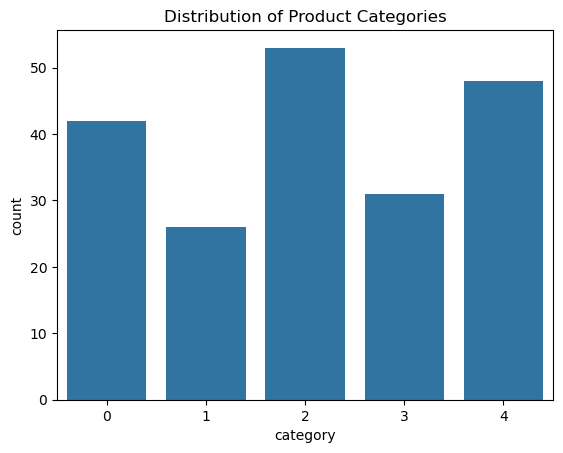

In [ ]:
import pandas as pd #panas digunakan untuk manipulasi data
import matplotlib.pyplot as plt #matplotlib digunakan untuk visualisasi
import seaborn as sns #seaborn digunakan untuk visualisasi
from sklearn.preprocessing import LabelEncoder #preprocessing
# Load the dataset
df1 = pd.read_csv('products.csv') #membaca dataset
print(df1.head())
# Exploratory Data Analysis (EDA)
print(df1.isnull().sum()) #cek missing values
print(df1.info()) #cek tipe data
print(df1['category'].value_counts()) #cek distribusi kategori

#preprocessing
df1.drop(['product_id'], axis=1, inplace=True) #menghapus kolom yang tidak diperlukan
#merubah data kategorikal menjadi factor
le = LabelEncoder()
df1['category'] = le.fit_transform(df1['category'])
df1['brand'] = le.fit_transform(df1['brand'])
df1['product_name'] = le.fit_transform(df1['product_name'])
print(df1.head())
#visualisasi
sns.countplot(x='category', data=df1)
plt.title('Distribution of Product Categories')
plt.show()



In [ ]:
#split data
from sklearn.model_selection import train_test_split
X = df1.drop('category', axis=1)
y = df1['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#modeling KNN
from sklearn.neighbors import KNeighborsClassifier #mengimpor KNN classifier
#Menentukan nilai K
import numpy as np #untuk perhitungan nilai K
initial_k = int(np.sqrt(len(df1)))
print(initial_k)
knn = KNeighborsClassifier(n_neighbors=initial_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

#evaluasi model KNN
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report #untuk evaluasi model

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



14
Confusion Matrix:
 [[1 0 2 0 3]
 [3 0 2 1 1]
 [2 1 3 1 1]
 [2 1 5 0 0]
 [4 2 4 0 1]]
Accuracy: 0.125

Classification Report:

              precision    recall  f1-score   support

           0       0.08      0.17      0.11         6
           1       0.00      0.00      0.00         7
           2       0.19      0.38      0.25         8
           3       0.00      0.00      0.00         8
           4       0.17      0.09      0.12        11

    accuracy                           0.12        40
   macro avg       0.09      0.13      0.10        40
weighted avg       0.10      0.12      0.10        40



In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score 
cv_scores = cross_val_score(knn, X, y, cv=10)
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", np.mean(cv_scores))

Cross-validation scores: [0.3  0.2  0.3  0.2  0.35 0.15 0.15 0.05 0.25 0.3 ]
Average cross-validation score: 0.225


Dataset ini diambil dari platfrom kaggel chocolate data sales 2023-2024 dan saya mengambil data products untuk diklasifikasikan berdasarkan category. Berdasarkan hasil pengujian, model K-Nearest Neighbors (KNN) menghasilkan akurasi sebesar 12.5% pada data uji dan 22.03% pada cross-validation. Nilai akurasi yang rendah menunjukkan bahwa model belum mampu menangkap pola dengan baik antara fitur produk dan kategori. Hal ini kemungkinan disebabkan oleh jumlah data yang terbatas, fitur yang kurang representatif, serta karakteristik algoritma KNN yang sensitif terhadap ukuran dataset.